In [61]:
pip install numpy pandas matplotlib seaborn yfinance tweepy transformers datasets scikit-learn torch


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [62]:
pip install polygon-api-client

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [63]:
from polygon import RESTClient


API_KEY = "hxGeYKs1qclcdpNgPzniVjNvtgIcbulg"
client = RESTClient(API_KEY)

In [64]:
pip install "keras<3.0.0" praw


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from transformers import pipeline
from datetime import date
import matplotlib.pyplot as plt
from polygon import RESTClient
from transformers import pipeline, AutoTokenizer
import pandas as pd


In [66]:
df = pd.read_csv('/Users/sahilgulati/Desktop/Stock_Testing_vsc/Stock-testing/nasdaq-listed.csv')
print(df.head())

  Symbol                                      Security Name
0  AACBU                 Artius II Acquisition Inc. - Units
1   AACG  ATA Creativity Global - American Depositary Sh...
2   AADI               Aadi Bioscience, Inc. - Common Stock
3   AADR                AdvisorShares Dorsey Wright ADR ETF
4    AAL       American Airlines Group, Inc. - Common Stock


In [67]:
tickers_nasdaq = df['Symbol'].tolist()
print(tickers_nasdaq[0:10])

['AACBU', 'AACG', 'AADI', 'AADR', 'AAL', 'AAME', 'AAOI', 'AAON', 'AAPB', 'AAPD']


In [68]:
from transformers import pipeline

sentiment_analyser = pipeline("sentiment-analysis",model="distilbert-base-uncased-finetuned-sst-2-english")

Device set to use mps:0


In [69]:
from datetime import date
import praw
import re
from collections import Counter

# Reddit API Setup
reddit = praw.Reddit(
    client_id="_f9G2wmqD_D-8BU7usAkuw",
    client_secret="gLt3IkPt4B-GrPV-yQ44-LUy2XXmnQ",
    user_agent="sahilprostar/1.0"
)

# Load NASDAQ tickers (assuming tickers_nasdaq is already loaded from CSV)
Subreddit = input("Enter the subreddit name (default: WallStreetBets): ") or "wallstreetbets"
subreddit_chosen = reddit.subreddit(Subreddit)
hot_posts = subreddit_chosen.hot(limit=50)

# Extract NASDAQ tickers from Reddit (Titles, Bodies, and Comments)
tickers_reddit = []

for post in hot_posts:
    # Extract tickers from post title
    words_title = re.findall(r'\b[A-Z]{2,5}\b', post.title)
    valid_tickers_title = [word for word in words_title if word in tickers_nasdaq]
    tickers_reddit.extend(valid_tickers_title)

    # Extract tickers from post body (selftext)
    if post.selftext:
        words_body = re.findall(r'\b[A-Z]{2,5}\b', post.selftext)
        valid_tickers_body = [word for word in words_body if word in tickers_nasdaq]
        tickers_reddit.extend(valid_tickers_body)

    # Extract tickers from comments
    post.comments.replace_more(limit=0)  # Load all comments
    for comment in post.comments.list():
        if comment.body:
            words_comment = re.findall(r'\b[A-Z]{2,5}\b', comment.body)
            valid_tickers_comment = [word for word in words_comment if word in tickers_nasdaq]
            tickers_reddit.extend(valid_tickers_comment)

# Count top mentioned stocks
top_stocks = Counter(tickers_reddit).most_common(10)

# Display results
print("\n📅 Date:", date.today())
print("📈📉 Top 10 Mentioned Stocks on Reddit (Titles, Bodies & Comments):")
for idx, (stock, count) in enumerate(top_stocks, 1):
    print(f"{idx}. {stock} ({count} mentions)")



📅 Date: 2025-03-19
📈📉 Top 10 Mentioned Stocks on Reddit (Titles, Bodies & Comments):
1. TSLA (340 mentions)
2. OP (62 mentions)
3. EU (45 mentions)
4. MSTR (39 mentions)
5. NVDA (28 mentions)
6. TLT (23 mentions)
7. TSLR (14 mentions)
8. GOOG (11 mentions)
9. QQQ (10 mentions)
10. INTC (8 mentions)


Device set to use mps:0



📅 Date: 2025-03-19
📈📉 Top 10 Mentioned Stocks on Reddit with Sentiment Analysis:
1. TSL: Bearish 📉 (51 Positive, 282 Negative)
2. TSLA: Bearish 📉 (48 Positive, 265 Negative)
3. PY: Bearish 📉 (9 Positive, 71 Negative)
4. OP: Bearish 📉 (15 Positive, 60 Negative)
5. TC: Bearish 📉 (5 Positive, 66 Negative)
6. TH: Bearish 📉 (12 Positive, 55 Negative)
7. OM: Bearish 📉 (10 Positive, 47 Negative)
8. ON: Bearish 📉 (7 Positive, 47 Negative)
9. Z: Bearish 📉 (13 Positive, 41 Negative)
10. CA: Bearish 📉 (9 Positive, 35 Negative)


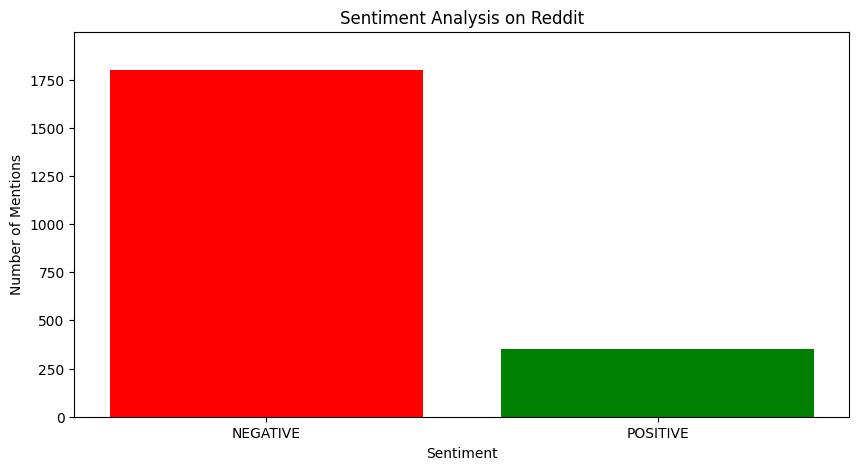

In [70]:
from collections import defaultdict, Counter
import praw
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline, AutoTokenizer
from datetime import date

# Polygon API Setup
API_KEY = "hxGeYKs1qclcdpNgPzniVjNvtgIcbulg"
client = RESTClient(API_KEY)

# Reddit API Setup
reddit = praw.Reddit(
    client_id="_f9G2wmqD_D-8BU7usAkuw",
    client_secret="gLt3IkPt4B-GrPV-yQ44-LUy2XXmnQ",
    user_agent="sahilprostar/1.0"
)

# Load NASDAQ tickers from CSV
df = pd.read_csv('/Users/sahilgulati/Desktop/Stock_Testing_vsc/Stock-testing/nasdaq-listed.csv')

# Ensure tickers are strings and remove NaN values
tickers_nasdaq = [str(ticker).strip() for ticker in df['Symbol'].dropna().tolist()]

# Load tokenizer for better text splitting
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def split_text_into_chunks(text, max_length=510):
    """Splits text into smaller chunks using tokenizer encoding, ensuring no overflow."""
    tokenized_text = tokenizer.encode(text, truncation=True, max_length=max_length)
    chunks = [tokenizer.decode(tokenized_text[i:i+max_length]) for i in range(0, len(tokenized_text), max_length)]
    return chunks

# Get subreddit name from user input
Subreddit = input("Enter the subreddit name (default: WallStreetBets): ") or "wallstreetbets"
subreddit_chosen = reddit.subreddit(Subreddit)
hot_posts = subreddit_chosen.hot(limit=50)

tickers_reddit = []
stock_sentiments = defaultdict(list)

# Load BERT for sentiment analysis
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Process Reddit posts (Titles, Bodies, and Comments)
for post in hot_posts:
    post_title = post.title.strip()
    post_body = post.selftext.strip() if post.selftext else ""
    
    # Combine title and body for analysis
    full_post_text = f"{post_title} {post_body}"
    
    # Get sentiment of combined text (splitting into tokenized chunks)
    if full_post_text:
        body_chunks = split_text_into_chunks(full_post_text, 510)
        chunk_sentiments = [sentiment_analyzer(chunk)[0]['label'] for chunk in body_chunks]
    else:
        chunk_sentiments = []
    
    # Store sentiment results for stock tickers mentioned
    for ticker in tickers_nasdaq:
        if ticker in full_post_text:
            tickers_reddit.append(ticker)  # Store the mention for counting
            stock_sentiments[ticker].extend(chunk_sentiments)
    
    # Analyze comments for sentiment
    post.comments.replace_more(limit=0)  # Load all top-level comments
    for comment in post.comments.list():
        comment_text = comment.body.strip()
        
        if comment_text:
            comment_chunks = split_text_into_chunks(comment_text, 510)
            comment_sentiments = [sentiment_analyzer(chunk)[0]['label'] for chunk in comment_chunks]
        
            for ticker in tickers_nasdaq:
                if ticker in comment_text:
                    tickers_reddit.append(ticker)  
                    stock_sentiments[ticker].extend(comment_sentiments)


# Count mentions of stocks
top_stocks = Counter(tickers_reddit).most_common(10)

# Analyze sentiment per stock
stock_sentiment_summary = {}
for stock, sentiments in stock_sentiments.items():
    positive_count = sentiments.count("POSITIVE")
    negative_count = sentiments.count("NEGATIVE")
    total_count = len(sentiments)

    # Determine overall sentiment
    if positive_count > negative_count:
        overall_sentiment = "Bullish 📈"
    elif negative_count > positive_count:
        overall_sentiment = "Bearish 📉"
    else:
        overall_sentiment = "Neutral ⚖️"

    stock_sentiment_summary[stock] = {
        "Positive Mentions": positive_count,
        "Negative Mentions": negative_count,
        "Total Mentions": total_count,
        "Overall Sentiment": overall_sentiment
    }

# Display sentiment results
print("\n📅 Date:", date.today())
print("📈📉 Top 10 Mentioned Stocks on Reddit with Sentiment Analysis:")
for idx, (stock, data) in enumerate(sorted(stock_sentiment_summary.items(), key=lambda x: x[1]["Total Mentions"], reverse=True)[:10], 1):
    print(f"{idx}. {stock}: {data['Overall Sentiment']} ({data['Positive Mentions']} Positive, {data['Negative Mentions']} Negative)")

# Graph Sentiment Analysis
sentiment_counts = Counter([sent for sent_list in stock_sentiments.values() for sent in sent_list])
plt.figure(figsize=(10, 5))
plt.bar(sentiment_counts.keys(), sentiment_counts.values(), color=['red', 'green', 'gray'])
plt.title("Sentiment Analysis on Reddit")
plt.xlabel("Sentiment")
plt.ylabel("Number of Mentions")
plt.ylim(0, max(sentiment_counts.values()) + 200)
plt.show()


In [71]:
import time

selected_stock = input("Enter a stock ticker to analyze: ").upper()
if selected_stock in tickers_nasdaq:
    # Fetch latest news
    news = client.list_ticker_news(selected_stock, limit=50)  # Fetch up to 50 articles (adjust as needed)
    
    # Counter to limit the number of articles printed
    max_articles = 10  # Set the maximum number of articles to display
    count = 0
    
    for item in news:
        if count >= max_articles:
            break  # Stop after printing the desired number of articles
        print(f"📰 {item.published_utc} | {item.title}\n{item.description}\n")
        time.sleep(0.2)
        count += 1
else:
    print("⚠️ Invalid ticker symbol.")

📰 2025-03-19T18:53:57Z | How The Smart Money Gets Rich When Markets Crash
This article discusses how savvy investors can profit during market crashes by identifying undervalued companies and buying them at discounted prices. It highlights examples of investors like Warren Buffett and Richard Rainwater who have successfully executed this strategy.

📰 2025-03-19T13:19:00Z | Is This Simple Index Fund a Millionaire Maker?
The Vanguard Developed Markets ETF offers exposure to international markets, but may not be the best long-term investment option compared to the Vanguard S&P 500 ETF. While it provides diversification and higher dividend yields, the international fund has underperformed the S&P 500 over the long run.

📰 2025-03-19T08:45:00Z | Prediction: Buying This Vanguard ETF Today Will Set You Up for Life
The article discusses the Vanguard Russell 1000 Growth ETF (VONG) as a potential long-term investment opportunity, highlighting its strong historical performance and the growth prosp

In [72]:
F_report = input("Do you want a basic fundamental report (Y/N): ").upper()
if F_report == "Y":
  fundamentals = client.get_ticker_details(selected_stock)
  print("🔍 Fundamental Analysis:")
  print(f"📌 Name: {fundamentals.name}")
  print(f"🏢 Industry: {fundamentals.sic_description}")
  print(f"💰 Market Cap: ${fundamentals.market_cap}")
  #comment


In [73]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start = '2022-12-22'
end = date.today()
stock = selected_stock

data = yf.download(stock, start, end)

# Calculate Moving Averages
EMA_50 = data['Close'].ewm(span=50, adjust=False).mean()
EMA_100 = data['Close'].ewm(span=100, adjust=False).mean()

# Calculate Moving Averages
EMA_20 = data['Close'].ewm(span=20, adjust=False).mean()
EMA_10 = data['Close'].ewm(span=10, adjust=False).mean()





[*********************100%***********************]  1 of 1 completed


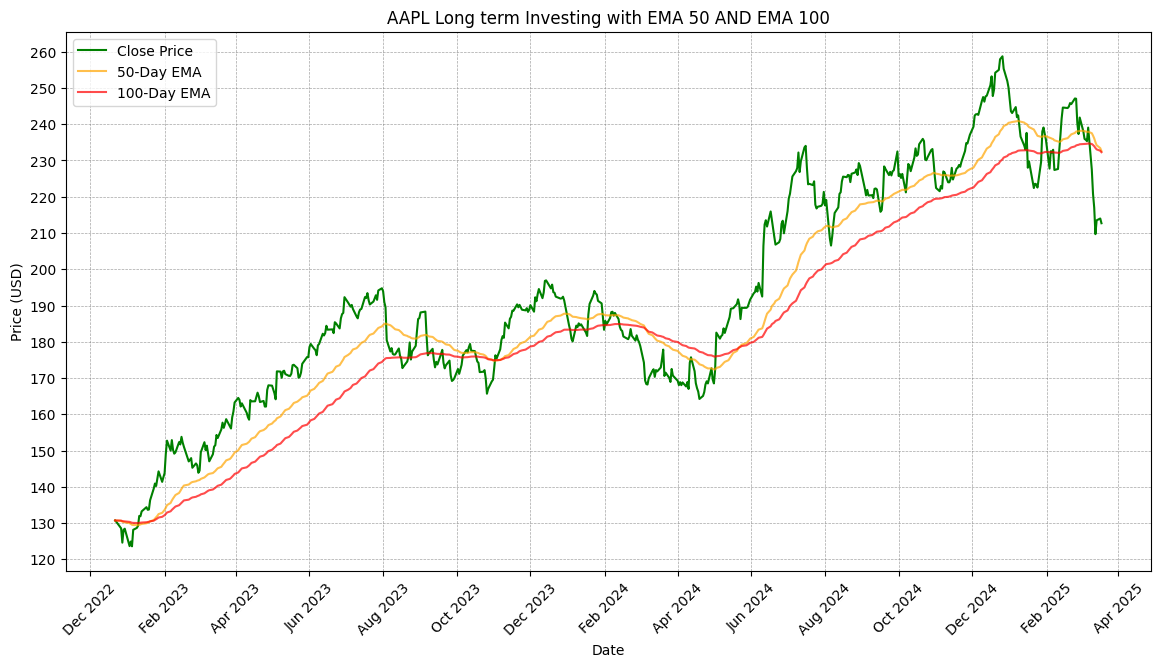

In [74]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='g')
plt.plot(EMA_50, label='50-Day EMA', color='orange', alpha=0.7)
plt.plot(EMA_100, label='100-Day EMA', color='r', alpha=0.7)

plt.title(f' Long term Investing with EMA 50 AND EMA 100')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Ticks at the start of each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Month Year'


# Adjust tick intervals to decrease grid box size
plt.xticks(ticks=plt.xticks()[0], rotation=45)  # Rotate x-axis labels for readability
plt.locator_params(axis='x', nbins=20)  # Increase x-axis grid density
plt.locator_params(axis='y', nbins=15)  # Increase y-axis grid density
plt.xticks(rotation=45)
plt.show()

In [75]:
# Calculate RSI
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

In [76]:
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

# Define Buy and Sell Signals based on conditions
data['Buy_Signal'] = (data['EMA_20'] > data['EMA_50']) & (data['RSI'] < 40)


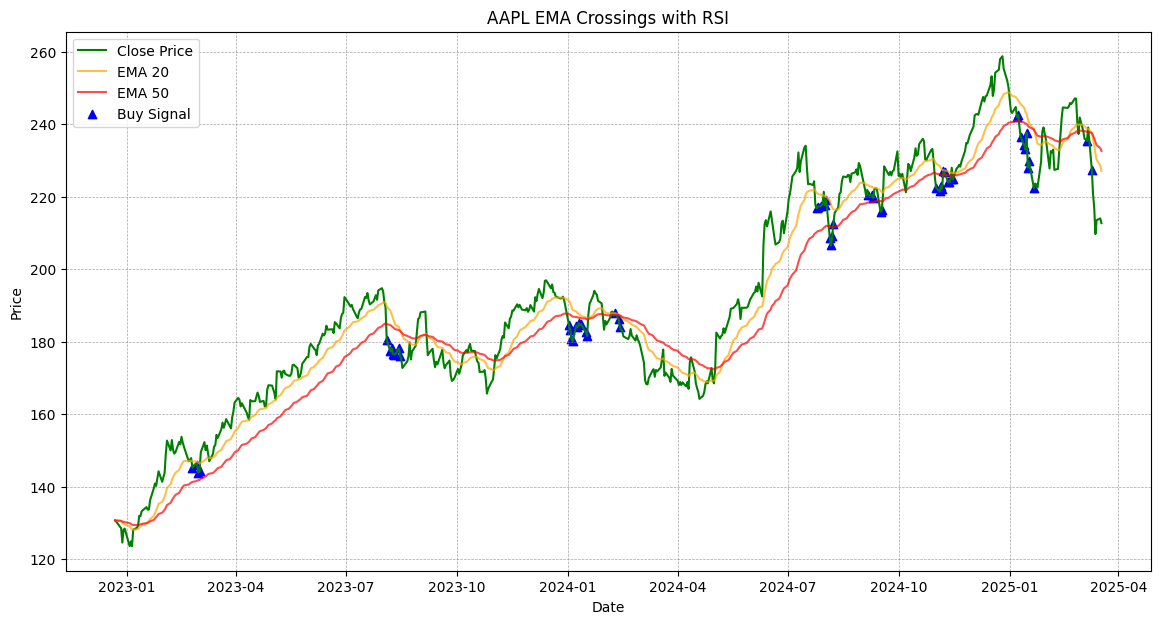

In [77]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='g')
plt.plot(data['EMA_20'], label='EMA 20', color='orange', alpha=0.7)
plt.plot(data['EMA_50'], label='EMA 50', color='red', alpha=0.7)

# Add buy and sell signals
plt.scatter(data.index[data['Buy_Signal']], data['Close'][data['Buy_Signal']],
            label='Buy Signal', marker='^', color='blue', alpha=1)


plt.title(f' EMA Crossings with RSI')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()


In [78]:
def analyze_fundamentals(ticker):
    """
    Perform fundamental analysis for a given stock ticker.
    
    Args:
        ticker (str): The stock ticker symbol (e.g., "AAPL").
    
    Returns:
        dict: A dictionary containing the financial analysis results.
    """
    # Fetch financial data
    data = []
    for t in client.vx.list_stock_financials(ticker=ticker, filing_date_gte='2025-01-01'):
        data.append(t)

    if not data:
        print(f"No financial data found for {ticker}.")
        return None

    # Extract financial statements
    income_statement = data[0].financials.income_statement
    balance_sheet = data[0].financials.balance_sheet
    cash_flow_statement = data[0].financials.cash_flow_statement

    # Calculate key metrics
    profit_margin = (income_statement.net_income_loss.value / income_statement.revenues.value) * 100
    current_ratio = balance_sheet.current_assets.value / balance_sheet.current_liabilities.value
    debt_to_equity = balance_sheet.liabilities.value / balance_sheet.equity.value

    # Prepare analysis results
    analysis = {
        "Income Statement": {
            "Revenues": income_statement.revenues.value,
            "Cost of Revenue": income_statement.cost_of_revenue.value,
            "Gross Profit": income_statement.gross_profit.value,
            "Operating Expenses": income_statement.operating_expenses.value,
            "Operating Income": income_statement.operating_income_loss.value,
            "Net Income": income_statement.net_income_loss.value,
        },
        "Balance Sheet": {
            "Total Assets": balance_sheet.assets.value,
            "Total Liabilities": balance_sheet.liabilities.value,
            "Equity": balance_sheet.equity.value,
        },
        "Cash Flow Statement": {
            "Net Cash Flow from Operating Activities": cash_flow_statement.net_cash_flow_from_operating_activities.value,
            "Net Cash Flow from Investing Activities": cash_flow_statement.net_cash_flow_from_investing_activities.value,
            "Net Cash Flow from Financing Activities": cash_flow_statement.net_cash_flow_from_financing_activities.value,
            "Net Cash Flow": cash_flow_statement.net_cash_flow.value,
        },
        "Key Metrics": {
            "Profit Margin": profit_margin,
            "Current Ratio": current_ratio,
            "Debt to Equity Ratio": debt_to_equity,
        },
        "Investment Recommendation": None,
    }

    # Decision-making logic
    if profit_margin > 10 and current_ratio > 1.5 and debt_to_equity < 2:
        analysis["Investment Recommendation"] = "✅ The company has strong financials and is a good investment."
    elif profit_margin > 5 and current_ratio > 1 and debt_to_equity < 3:
        analysis["Investment Recommendation"] = "🟡 The company has moderate financials. Consider further analysis before investing."
    else:
        analysis["Investment Recommendation"] = "❌ The company has weak financials. It may not be a safe investment."

    return analysis

In [79]:
def display_fundamentals(analysis):
    """
    Display the fundamental analysis results in a user-friendly format.
    
    Args:
        analysis (dict): The analysis results returned by `analyze_fundamentals()`.
    """
    if not analysis:
        print("No analysis to display.")
        return

    print("\n📊 Fundamental Analysis:")
    
    # Income Statement
    print("\n📄 Income Statement:")
    for key, value in analysis["Income Statement"].items():
        print(f"{key}: ${value:,.2f}")

    # Balance Sheet
    print("\n📄 Balance Sheet:")
    for key, value in analysis["Balance Sheet"].items():
        print(f"{key}: ${value:,.2f}")

    # Cash Flow Statement
    print("\n📄 Cash Flow Statement:")
    for key, value in analysis["Cash Flow Statement"].items():
        print(f"{key}: ${value:,.2f}")

    # Key Metrics
    print("\n📈 Key Metrics:")
    for key, value in analysis["Key Metrics"].items():
        if key == "Profit Margin":
            print(f"{key}: {value:.2f}%")
        else:
            print(f"{key}: {value:.2f}")

    # Investment Recommendation
    print("\n📌 Investment Recommendation:")
    print(analysis["Investment Recommendation"])

In [80]:
# Example usage
ticker = selected_stock  # Replace with the desired stock ticker
analysis = analyze_fundamentals(ticker)
if analysis:
    display_fundamentals(analysis)


📊 Fundamental Analysis:

📄 Income Statement:
Revenues: $124,300,000,000.00
Cost of Revenue: $66,025,000,000.00
Gross Profit: $58,275,000,000.00
Operating Expenses: $15,443,000,000.00
Operating Income: $42,832,000,000.00
Net Income: $36,330,000,000.00

📄 Balance Sheet:
Total Assets: $344,085,000,000.00
Total Liabilities: $277,327,000,000.00
Equity: $66,758,000,000.00

📄 Cash Flow Statement:
Net Cash Flow from Operating Activities: $29,935,000,000.00
Net Cash Flow from Investing Activities: $9,792,000,000.00
Net Cash Flow from Financing Activities: $-39,371,000,000.00
Net Cash Flow: $356,000,000.00

📈 Key Metrics:
Profit Margin: 29.23%
Current Ratio: 0.92
Debt to Equity Ratio: 4.15

📌 Investment Recommendation:
❌ The company has weak financials. It may not be a safe investment.


In [81]:
from datetime import date
import pandas as pd
import yfinance as yf

def get_stock_data(ticker, start="2023-01-01", end=date.today()):
    stock = yf.download(ticker, start=start, end=end)

    # Calculate EMA (if not already in your notebook)
    stock["EMA"] = stock["Close"].ewm(span=20, adjust=False).mean()

    return stock
def calculate_rsi(data, window=14):
    delta = data["Close"].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    data["RSI"] = rsi
    return data

In [82]:
def calculate_fibonacci_levels(data):
    high = data["Close"].max()
    low = data["Close"].min()

    fib_levels = {
        "0%": high,
        "23.6%": high - (0.236 * (high - low)),
        "38.2%": high - (0.382 * (high - low)),
        "50%": high - (0.5 * (high - low)),
        "61.8%": high - (0.618 * (high - low)),
        "100%": low,
    }

    # Convert Series to scalars if needed
    fib_levels = {k: v.item() if isinstance(v, pd.Series) else v for k, v in fib_levels.items()}

    return fib_levels

In [83]:
stock_data = get_stock_data(selected_stock)
stock_data = calculate_rsi(stock_data)
fib_levels = calculate_fibonacci_levels(stock_data)
print(fib_levels)  # Check output

print(stock_data.tail())  # View last few rows to check signals

[*********************100%***********************]  1 of 1 completed

{'0%': 258.7355041503906, '23.6%': 226.83953482055665, '38.2%': 207.10728260803222, '50%': 191.15929794311523, '61.8%': 175.21131327819825, '100%': 123.58309173583984}
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2025-03-12  216.979996  221.750000  214.910004  220.139999  62547500   
2025-03-13  209.679993  216.839996  208.419998  215.949997  61368300   
2025-03-14  213.490005  213.949997  209.580002  211.250000  60107600   
2025-03-17  214.000000  215.220001  209.970001  213.309998  48073400   
2025-03-18  212.690002  215.149994  211.490005  214.160004  42432400   

Price              EMA        RSI  
Ticker                             
Date                               
2025-03-12  234.236859  20.263863  
2025-03-13  231.898109  17.702142  
2025-03-14  230.144957  20.920586  
2025-03-17  228.607342  21.634624  
202

[*********************100%***********************]  1 of 1 completed


{'0%': 258.7355041503906, '23.6%': 226.83953482055665, '38.2%': 207.10728260803222, '50%': 191.15929794311523, '61.8%': 175.21131327819825, '100%': 123.58309173583984}


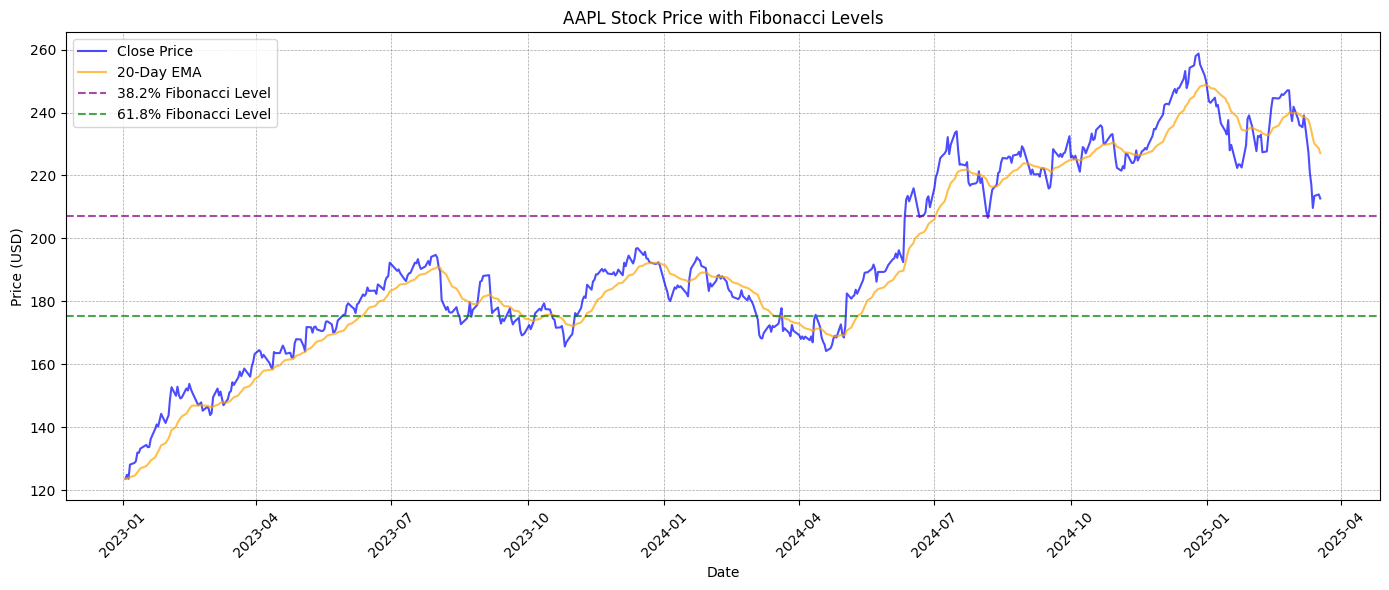

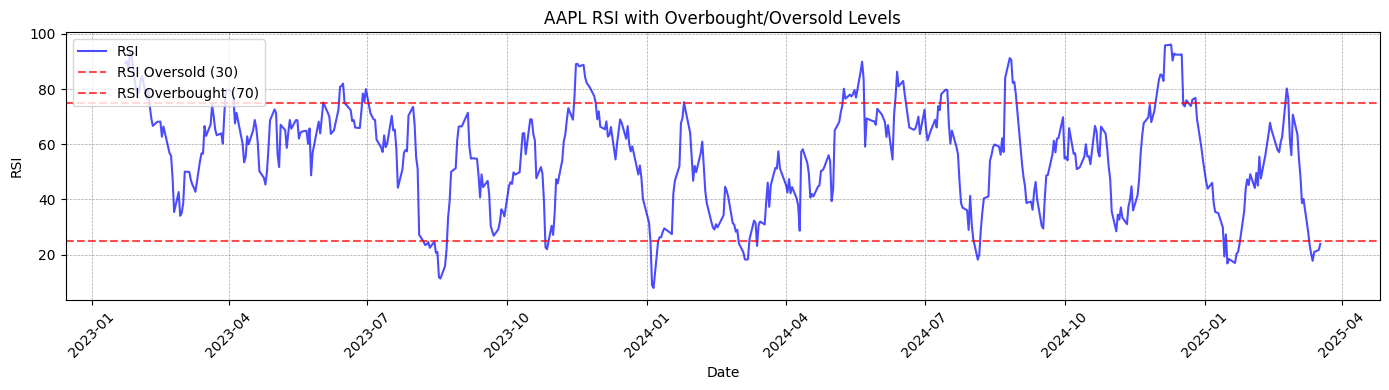

In [91]:
def plot_price_with_fibonacci(data, ema_column="EMA"):
    # Calculate Fibonacci levels
    fib_levels = calculate_fibonacci_levels(data)
    fib_38_2 = fib_levels["38.2%"]
    fib_61_8 = fib_levels["61.8%"]

    # Create a figure and axis
    plt.figure(figsize=(14, 6))

    # Plot the closing price
    plt.plot(data.index, data["Close"], label="Close Price", color="blue", alpha=0.7)

    # Plot the EMA
    plt.plot(data.index, data[ema_column], label="20-Day EMA", color="orange", alpha=0.7)

    # Plot Fibonacci levels
    plt.axhline(y=fib_38_2, color="purple", linestyle="--", label="38.2% Fibonacci Level", alpha=0.7)
    plt.axhline(y=fib_61_8, color="green", linestyle="--", label="61.8% Fibonacci Level", alpha=0.7)

    # Add labels, title, and legend
    plt.title(f"Stock Price with Fibonacci Levels")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend(loc="upper left")
    plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()

def plot_rsi(data, rsi_column="RSI"):
    # Create a figure and axis
    plt.figure(figsize=(14, 4))

    # Plot the RSI
    plt.plot(data.index, data[rsi_column], label="RSI", color="blue", alpha=0.7)

    # Plot RSI levels
    plt.axhline(y=25, color="red", linestyle="--", label="RSI Oversold (30)", alpha=0.7)
    plt.axhline(y=75, color="red", linestyle="--", label="RSI Overbought (70)", alpha=0.7)

    # Add labels, title, and legend
    plt.title(f"RSI with Overbought/Oversold Levels")
    plt.xlabel("Date")
    plt.ylabel("RSI")
    plt.legend(loc="upper left")
    plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()

stock_data = get_stock_data(selected_stock)
stock_data = calculate_rsi(stock_data)
fib_levels = calculate_fibonacci_levels(stock_data)
print(fib_levels)  # Check output

# Plot the price with Fibonacci levels
plot_price_with_fibonacci(stock_data)

# Plot the RSI
plot_rsi(stock_data)

In [100]:
def get_portfolio_input():
    """
    Collect portfolio details from the user.
    
    Returns:
        dict: A dictionary where keys are stock tickers and values are tuples of (shares, avg_price).
    """
    portfolio = {}
    while True:
        ticker = input("Enter a stock ticker (or type 'done' to finish): ").upper()
        if ticker == "DONE":
            break
        try:
            shares = float(input(f"Enter the number of shares for {ticker}: "))
            avg_price = float(input(f"Enter the average price per share for {ticker}: $"))
            if shares <= 0 or avg_price <= 0:
                print("Shares and average price must be greater than 0. Please try again.")
                continue
            portfolio[ticker] = (shares, avg_price)
        except ValueError:
            print("Invalid input. Please enter a valid number.")
    return portfolio


def get_current_price(ticker):
    stock = yf.Ticker(ticker)
    return stock.history(period="1d")['Close'].iloc[-1]

def calculate_portfolio_performance(portfolio):
    """
    Calculate the performance of each stock in the portfolio.
    
    Args:
        portfolio (dict): A dictionary where keys are stock tickers and values are tuples of (shares, avg_price).
    
    Returns:
        dict: A dictionary containing performance data for each stock.
    """
    performance = {}
    for ticker, (shares, avg_price) in portfolio.items():
        try:
            # Fetch current price
            current_price = get_current_price(ticker)
            
            # Calculate current value and profit/loss
            current_value = shares * current_price
            amount_invested = shares * avg_price
            profit_loss = current_value - amount_invested

            # Store performance data
            performance[ticker] = {
                "Shares": shares,
                "Average Price": avg_price,
                "Current Price": current_price,
                "Amount Invested": amount_invested,
                "Current Value": current_value,
                "Profit/Loss": profit_loss
            }
        except Exception as e:
            print(f"Error analyzing {ticker}: {e}")
            performance[ticker] = {"Error": "Unable to analyze this stock."}
    return performance

In [98]:
def analyze_portfolio(portfolio):
    """
    Analyze the portfolio by performing both technical and fundamental analysis for each stock.
    
    Args:
        portfolio (dict): A dictionary where keys are stock tickers and values are tuples of (shares, avg_price).
    """
    performance = calculate_portfolio_performance(portfolio)
    
    for ticker, data in performance.items():
        print(f"\n📊 Analysis for {ticker}:")
        if "Error" in data:
            print(f"❌ {data['Error']}")
            continue

        print(f"Shares: {data['Shares']}")
        print(f"Average Price: ${data['Average Price']:.2f}")
        print(f"Current Price: ${data['Current Price']:.2f}")
        print(f"Amount Invested: ${data['Amount Invested']:.2f}")
        print(f"Current Value: ${data['Current Value']:.2f}")
        print(f"Profit/Loss: ${data['Profit/Loss']:.2f}")

        # Add Technical Analysis
        stock_data = get_stock_data(ticker)
        stock_data = calculate_rsi(stock_data)
        fib_levels = calculate_fibonacci_levels(stock_data)
        print(f"\n📈 Fibonacci Levels: {fib_levels}")
        plot_price_with_fibonacci(stock_data)
        plot_rsi(stock_data)

        # Add Fundamental Analysis
        print("\n🔍 Fundamental Analysis:")
        fundamental_analysis = analyze_fundamentals(ticker)
        
        if fundamental_analysis:
            # Display Income Statement
            print("\n📄 Income Statement:")
            for key, value in fundamental_analysis["Income Statement"].items():
                print(f"{key}: ${value:,.2f}")

            # Display Balance Sheet
            print("\n📄 Balance Sheet:")
            for key, value in fundamental_analysis["Balance Sheet"].items():
                print(f"{key}: ${value:,.2f}")

            # Display Cash Flow Statement
            print("\n📄 Cash Flow Statement:")
            for key, value in fundamental_analysis["Cash Flow Statement"].items():
                print(f"{key}: ${value:,.2f}")

            # Display Key Metrics
            print("\n📈 Key Metrics:")
            for key, value in fundamental_analysis["Key Metrics"].items():
                if key == "Profit Margin":
                    print(f"{key}: {value:.2f}%")
                else:
                    print(f"{key}: {value:.2f}")

            # Display Investment Recommendation
            print("\n📌 Investment Recommendation:")
            print(fundamental_analysis["Investment Recommendation"])
        else:
            print("❌ No fundamental data available for this stock.")

Welcome to the Portfolio Analyzer!


[*********************100%***********************]  1 of 1 completed


📊 Analysis for TSLA:
Shares: 1.0
Average Price: $500.00
Current Price: $235.86
Amount Invested: $500.00
Current Value: $235.86
Profit/Loss: $-264.14

📈 Fibonacci Levels: {'0%': 479.8599853515625, '23.6%': 392.1246284484863, '38.2%': 337.8476703643799, '50%': 293.9799919128418, '61.8%': 250.1123134613037, '100%': 108.0999984741211}


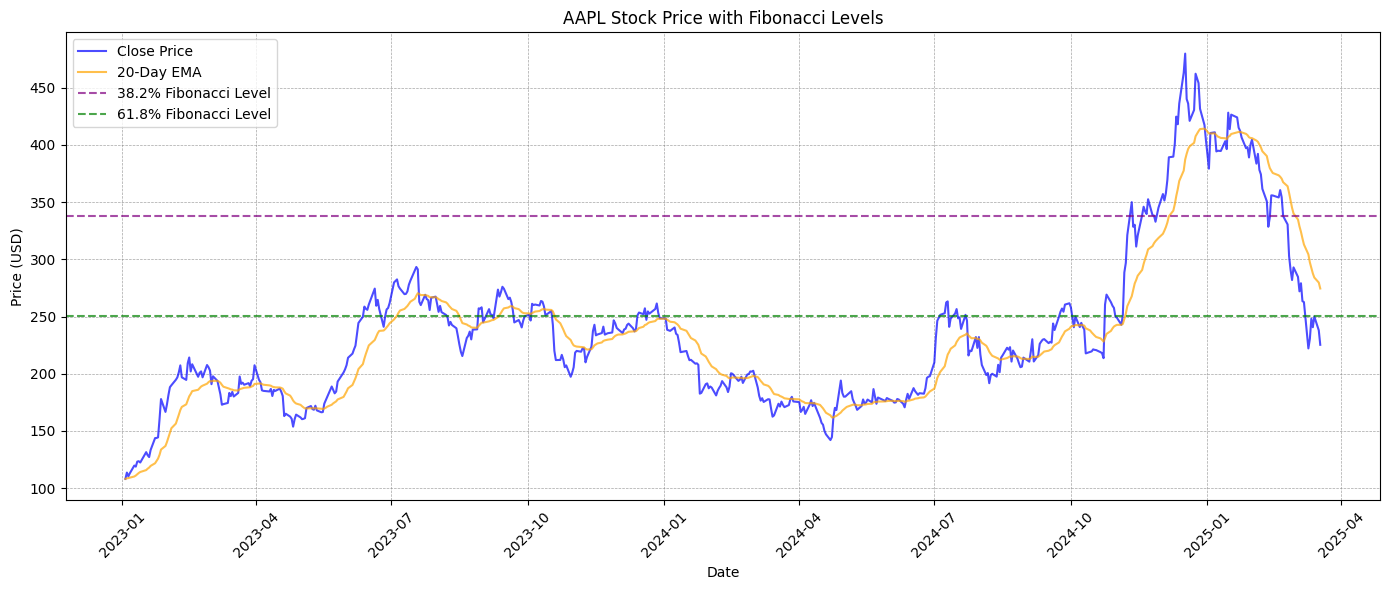

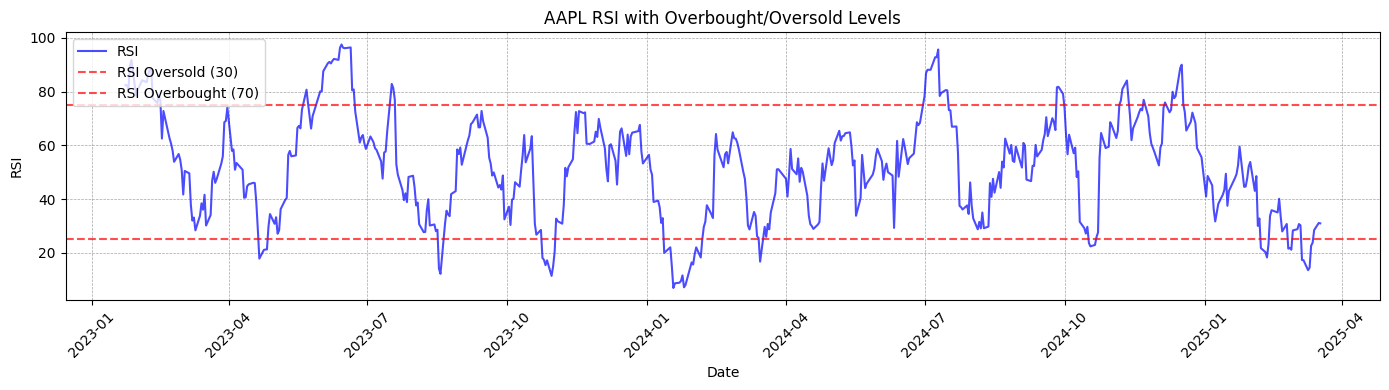


🔍 Fundamental Analysis:


[*********************100%***********************]  1 of 1 completed


📄 Income Statement:
Revenues: $97,690,000,000.00
Cost of Revenue: $80,240,000,000.00
Gross Profit: $17,450,000,000.00
Operating Expenses: $10,374,000,000.00
Operating Income: $7,076,000,000.00
Net Income: $7,153,000,000.00

📄 Balance Sheet:
Total Assets: $122,070,000,000.00
Total Liabilities: $48,390,000,000.00
Equity: $73,617,000,000.00

📄 Cash Flow Statement:
Net Cash Flow from Operating Activities: $14,923,000,000.00
Net Cash Flow from Investing Activities: $-18,787,000,000.00
Net Cash Flow from Financing Activities: $3,853,000,000.00
Net Cash Flow: $-11,000,000.00

📈 Key Metrics:
Profit Margin: 7.32%
Current Ratio: 2.02
Debt to Equity Ratio: 0.66

📌 Investment Recommendation:
🟡 The company has moderate financials. Consider further analysis before investing.

📊 Analysis for NVDA:
Shares: 50.0
Average Price: $10.00
Current Price: $117.52
Amount Invested: $500.00
Current Value: $5876.00
Profit/Loss: $5376.00

📈 Fibonacci Levels: {'0%': 149.41624450683594, '23.6%': 117.51779471206666,

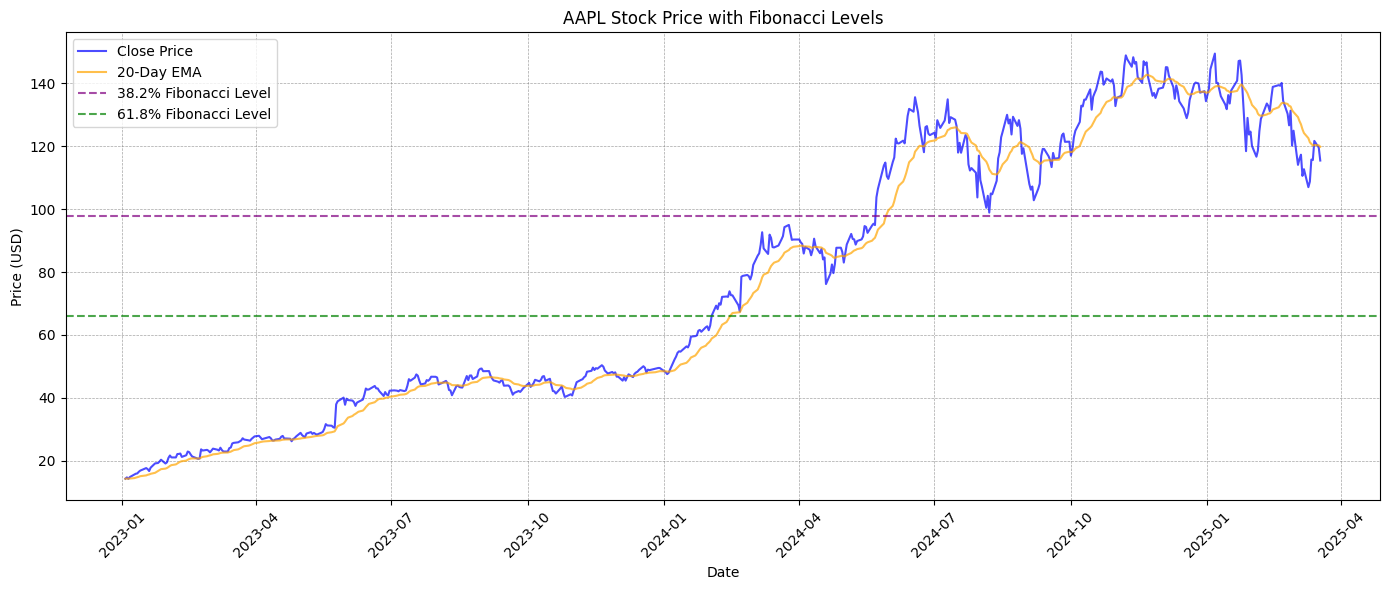

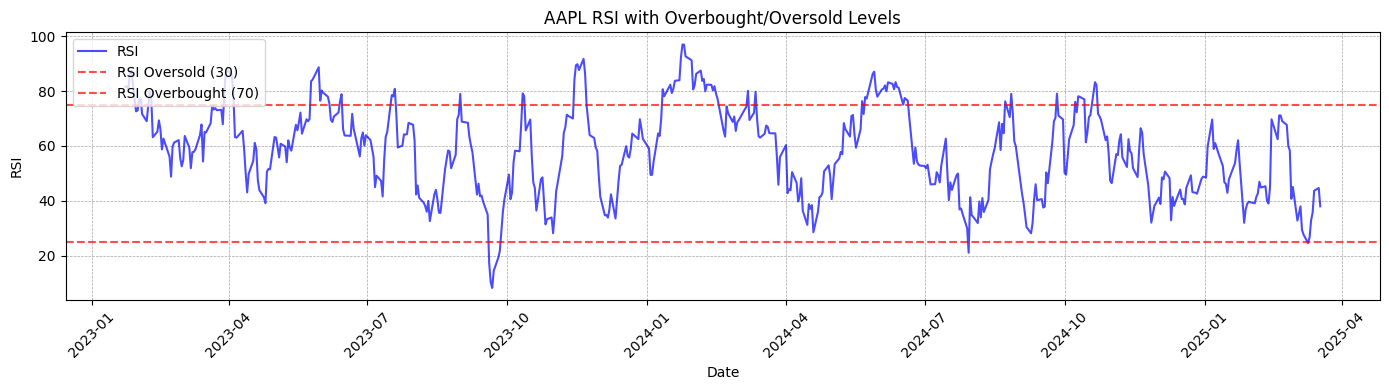


🔍 Fundamental Analysis:

📄 Income Statement:
Revenues: $130,497,000,000.00
Cost of Revenue: $32,639,000,000.00
Gross Profit: $97,858,000,000.00
Operating Expenses: $16,405,000,000.00
Operating Income: $81,453,000,000.00
Net Income: $72,880,000,000.00

📄 Balance Sheet:
Total Assets: $111,601,000,000.00
Total Liabilities: $32,274,000,000.00
Equity: $79,327,000,000.00

📄 Cash Flow Statement:
Net Cash Flow from Operating Activities: $64,089,000,000.00
Net Cash Flow from Investing Activities: $-20,421,000,000.00
Net Cash Flow from Financing Activities: $-42,359,000,000.00
Net Cash Flow: $1,309,000,000.00

📈 Key Metrics:
Profit Margin: 55.85%
Current Ratio: 4.44
Debt to Equity Ratio: 0.41

📌 Investment Recommendation:
✅ The company has strong financials and is a good investment.
No analysis to display.


In [99]:
def main():
    print("Welcome to the Portfolio Analyzer!")
    portfolio = get_portfolio_input()
    performance = analyze_portfolio(portfolio)
    display_fundamentals(performance)
if __name__ == "__main__":
    main()